In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce GTX 1650


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [4]:
df = pd.read_csv("/home/mohamed/master/master/Dataset/Combined Data/Combined_dataset.csv")


In [5]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 302.1 MB


In [6]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [7]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

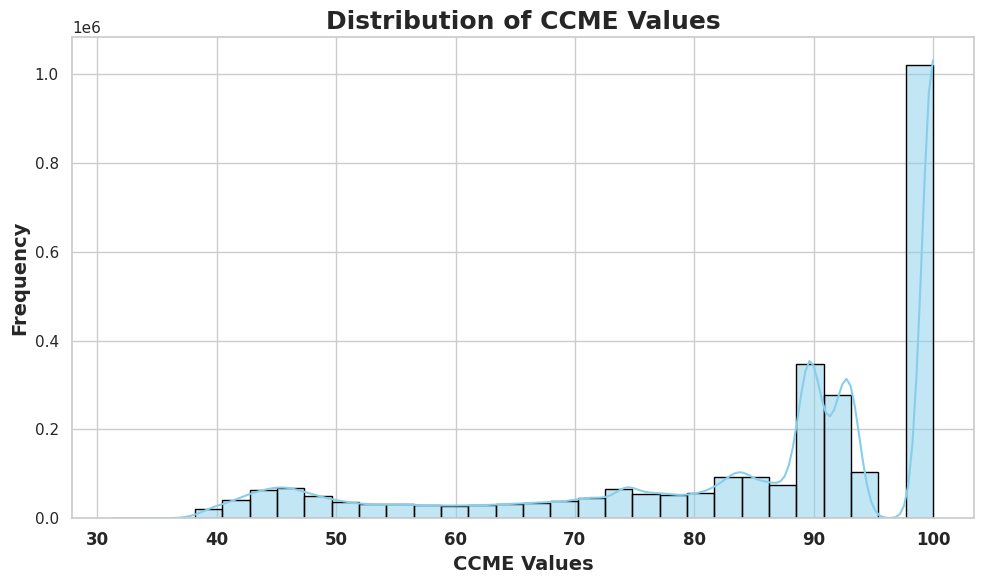

In [8]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



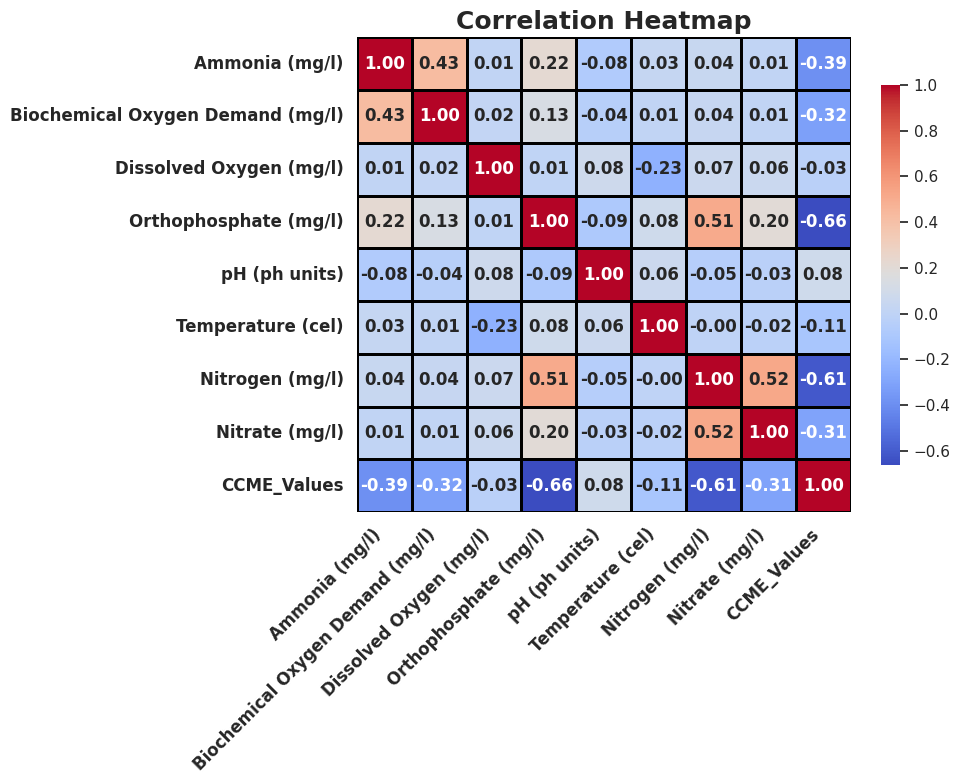

In [9]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [10]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [11]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [12]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [13]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


Windowing: 100%|██████████| 9005/9005 [04:54<00:00, 30.62area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)
[✔] sequences.pkl saved.


In [14]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [15]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [16]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 7: Model Architecture
#   MDFTformer – Multi-scale Decomposition Fusion Transformer
#   Based on: Li et al., "An accurate forecasting model for key water
#   quality factors based on Transformer with multi-scale attention
#   mechanism", Environmental Modelling and Software (2025)
#
#   Architecture overview:
#     Input → Dynamic Interpretable Time-Series Decomposition
#               ├── Trend Component    → Multi-Scale Linear Predictor
#               ├── Seasonal Component → Encoder-Decoder
#               │     ├── Multi-Scale Decomposition Self-Attention (MDSA)
#               │     └── Multi-Scale Temporal Fusion Self-Attention (MTFA)
#               └── Irregular Component → Difference + Conv
#     → Sum of three component predictions → Final Output
# ─────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F_func
import numpy as np

SEQ_LEN = 8    # must match the sliding window length defined in Section 5


# ══════════════════════════════════════════════════════════════════════
# 1. DYNAMIC INTERPRETABLE TIME-SERIES DECOMPOSITION
#    (Eqs. 1-8 in the paper)
# ══════════════════════════════════════════════════════════════════════

class DynamicDecomposition(nn.Module):
    """
    Decomposes the input into three components:
      - Trend (Holt exponential smoothing, Eqs. 1-5)
      - Seasonal (DFT-based, Eqs. 6-7)
      - Irregular = Original - Trend - Seasonal (Eq. 8)

    Input : x  [B, T, F]
    Output: (trend, seasonal, irregular) each [B, T, F]
    """
    def __init__(self, top_k: int = 3):
        super().__init__()
        self.top_k = top_k
        # Learnable Holt parameters (per feature)
        self.log_alpha = nn.Parameter(torch.zeros(1))   # sigmoid → α ∈ (0,1)
        self.log_gamma = nn.Parameter(torch.zeros(1))   # sigmoid → γ ∈ (0,1)

    def _holt_trend(self, x):
        """Vectorised Holt double-exponential smoothing — Eqs. 1-5."""
        alpha = torch.sigmoid(self.log_alpha)
        gamma = torch.sigmoid(self.log_gamma)
        B, T, F = x.shape
        S = x[:, 0, :]              # S_0 = y_0        [B, F]
        b = x[:, 1, :] - x[:, 0, :] # b_0 = y_1 - y_0 [B, F]
        trend_steps = [S]
        for t in range(1, T):
            S_new = alpha * x[:, t, :] + (1 - alpha) * (S + b)
            b     = gamma * (S_new - S) + (1 - gamma) * b
            S     = S_new
            trend_steps.append(S)
        return torch.stack(trend_steps, dim=1)          # [B, T, F]

    def _dft_seasonal(self, x):
        """DFT → keep top-k frequencies → IDFT. Eqs. 6-7."""
        # x: [B, T, F]
        xf  = torch.fft.rfft(x, dim=1)                 # [B, T//2+1, F]
        amp = xf.abs()                                  # magnitudes
        # zero out all but top-k frequencies per (B,F) position
        k   = min(self.top_k, amp.shape[1])
        _, idx = torch.topk(amp, k, dim=1)              # [B, k, F]
        mask = torch.zeros_like(amp)
        mask.scatter_(1, idx, 1.0)
        xf_sparse = xf * mask
        seasonal  = torch.fft.irfft(xf_sparse, n=x.shape[1], dim=1)
        return seasonal                                  # [B, T, F]

    def forward(self, x):
        trend    = self._holt_trend(x)
        seasonal = self._dft_seasonal(x)
        irregular = x - trend - seasonal
        return trend, seasonal, irregular


# ══════════════════════════════════════════════════════════════════════
# 2. MULTI-SCALE TREND PREDICTOR
#    (Eqs. 9-12 in the paper)
# ══════════════════════════════════════════════════════════════════════

class MultiScaleTrendPredictor(nn.Module):
    """
    Down-samples trend to M scales, predicts at each scale with a
    linear layer, then aggregates with softmax weights (Eqs. 9-12).

    Input : x_trend [B, T, F]
    Output: pred    [B, pred_len, F]
    """
    def __init__(self, input_dim: int, seq_len: int, pred_len: int = 1, n_scales: int = 4):
        super().__init__()
        self.n_scales = n_scales
        self.pred_len = pred_len
        self.input_dim = input_dim

        self.predictors = nn.ModuleList()
        for m in range(n_scales + 1):
            pool_size = max(1, 2 ** m)
            # compute T_m after average pooling
            T_m = max(1, seq_len // pool_size)
            in_features = T_m * input_dim
            out_features = pred_len * input_dim
            self.predictors.append(nn.Linear(in_features, out_features))

        # weight network for adaptive scale weighting
        self.weight_net = nn.Linear(input_dim, n_scales + 1)

    def forward(self, x_trend):
        # x_trend: [B, T, F]
        B, T, F = x_trend.shape
        scale_preds = []
        for m, predictor in enumerate(self.predictors):
            pool_size = max(1, 2 ** m)
            if pool_size > 1 and T > pool_size:
                x_m = F_avg_pool(x_trend, pool_size)   # [B, T_m, F]
            else:
                x_m = x_trend                           # [B, T, F]
            # ensure shape matches what Linear expects
            T_m_actual = x_m.shape[1]
            T_m_expected = max(1, T // pool_size)
            # pad or trim if needed due to rounding
            if T_m_actual < T_m_expected:
                pad_size = T_m_expected - T_m_actual
                x_m = torch.cat([x_m, x_m[:, -1:, :].expand(-1, pad_size, -1)], dim=1)
            elif T_m_actual > T_m_expected:
                x_m = x_m[:, :T_m_expected, :]
            x_flat = x_m.reshape(B, -1)                # [B, T_m*F]
            pred_m = predictor(x_flat)                 # [B, pred_len*F]
            pred_m = pred_m.view(B, self.pred_len, F)  # [B, pred_len, F]
            scale_preds.append(pred_m)

        scale_preds = torch.stack(scale_preds, dim=1)  # [B, M+1, pred_len, F]

        # adaptive weights via softmax(Linear(last_trend_step))
        w = self.weight_net(x_trend[:, -1, :])         # [B, M+1]
        w = torch.softmax(w, dim=-1)                    # [B, M+1]
        w = w[:, :, None, None]                         # [B, M+1, 1, 1]
        out = (w * scale_preds).sum(dim=1)              # [B, pred_len, F]
        return out                                      # [B, 1, F]


def F_avg_pool(x, pool_size):
    """1-D average pooling along the time axis."""
    B, T, Fdim = x.shape
    x_t = x.permute(0, 2, 1)          # [B, F, T]
    x_p = F_func.avg_pool1d(x_t, kernel_size=pool_size, stride=pool_size)
    return x_p.permute(0, 2, 1)       # [B, T//pool, F]


# ══════════════════════════════════════════════════════════════════════
# 3. MULTI-SCALE DECOMPOSITION SELF-ATTENTION  (MDSA)
#    (Eqs. 13-18 in the paper)
# ══════════════════════════════════════════════════════════════════════

class PatchAttention(nn.Module):
    """
    Single-scale patch-based self-attention.
    Splits the sequence into patches of size p,
    runs scaled dot-product inside each patch.
    """
    def __init__(self, d_model: int, n_heads: int, patch_size: int, dropout: float = 0.05):
        super().__init__()
        self.patch_size = patch_size
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.proj = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, d_model]
        B, T, D = x.shape
        p = self.patch_size
        # pad T to be divisible by p
        pad = (p - T % p) % p
        if pad > 0:
            x = F_func.pad(x, (0, 0, 0, pad))
        Tp = x.shape[1]
        N  = Tp // p
        # reshape: [B, N, p, D] → treat each patch as sequence of length p
        x_patch = x.view(B * N, p, D)           # [B*N, p, D]
        # learnable query that summarises the patch into 1 token
        q = x_patch.mean(dim=1, keepdim=True)   # [B*N, 1, D]
        out, _ = self.attn(q, x_patch, x_patch) # [B*N, 1, D]
        out = out.view(B, N, D)                  # [B, N, D]
        # project back to original sequence length by repeat-interleave
        out = out.repeat_interleave(p, dim=1)[:, :T, :]  # [B, T, D]
        return self.norm(self.proj(out) + x[:, :T, :])


class MDSABlock(nn.Module):
    """
    Multi-Scale Decomposition Self-Attention block.
    Runs PatchAttention at S different patch sizes and returns
    a list of S scale representations + the concatenated/averaged output.
    """
    def __init__(self, d_model: int, n_heads: int,
                 patch_sizes: list = None, dropout: float = 0.05):
        super().__init__()
        if patch_sizes is None:
            patch_sizes = [2, 4, 8, 16]
        self.patch_sizes = patch_sizes
        self.layers = nn.ModuleList([
            PatchAttention(d_model, n_heads, p, dropout)
            for p in patch_sizes
        ])
        self.out_proj = nn.Linear(d_model * len(patch_sizes), d_model)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, T, d_model]
        scale_outs = [layer(x) for layer in self.layers]   # list of [B, T, d_model]
        cat = torch.cat(scale_outs, dim=-1)                # [B, T, d_model*S]
        out = self.norm(self.out_proj(cat))                # [B, T, d_model]
        return out, scale_outs                             # (aggregated, per-scale list)


# ══════════════════════════════════════════════════════════════════════
# 4. MULTI-SCALE TEMPORAL FUSION SELF-ATTENTION  (MTFA)
#    (Eqs. 19-22 in the paper)
# ══════════════════════════════════════════════════════════════════════

class MTFABlock(nn.Module):
    """
    Multi-Scale Temporal Fusion Attention.
    Uses one scale output A from MDSA as an additional input:
      Step 1: A as query,   X as K/V  →  V_A  (aggregate multi-scale info)
      Step 2: X as query,   A as K,  V_A as V  →  head  (broadcast to every token)
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.05):
        super().__init__()
        self.attn1 = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.attn2 = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )
        self.norm_ff = nn.LayerNorm(d_model)

    def forward(self, x, A):
        """
        x : [B, T, d_model]   – embedded seasonal component
        A : [B, L, d_model]   – one scale output from MDSA (Eq. 19 context)
        """
        # Step 1: A (query) attends to x (K, V) → V_A
        V_A, _ = self.attn1(A, x, x)
        V_A    = self.norm1(V_A + A)

        # Step 2: x (query) attends to A (key), V_A (value)
        out, attn_w = self.attn2(x, A, V_A)
        out    = self.norm2(out + x)

        # Feed-forward
        out = self.norm_ff(out + self.ff(out))
        return out, attn_w


# ══════════════════════════════════════════════════════════════════════
# 5. SEASONAL ENCODER-DECODER
# ══════════════════════════════════════════════════════════════════════

class SeasonalEncoderDecoder(nn.Module):
    """
    Encoder-Decoder for the seasonal component.
    Encoder: embedding + MDSA + MTFA
    Decoder: same structure, outputs prediction
    """
    def __init__(self, input_dim: int, d_model: int, n_heads: int,
                 n_enc_layers: int = 3, n_dec_layers: int = 3,
                 patch_sizes: list = None, dropout: float = 0.05):
        super().__init__()
        # Embedding
        self.enc_embed = nn.Linear(input_dim, d_model)
        self.dec_embed = nn.Linear(input_dim, d_model)

        # Encoder layers
        self.enc_mdsa = nn.ModuleList([
            MDSABlock(d_model, n_heads, patch_sizes, dropout)
            for _ in range(n_enc_layers)
        ])
        self.enc_mtfa = nn.ModuleList([
            MTFABlock(d_model, n_heads, dropout)
            for _ in range(n_enc_layers)
        ])
        self.enc_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_enc_layers)])

        # Decoder layers
        self.dec_mdsa = nn.ModuleList([
            MDSABlock(d_model, n_heads, patch_sizes, dropout)
            for _ in range(n_dec_layers)
        ])
        self.dec_mtfa = nn.ModuleList([
            MTFABlock(d_model, n_heads, dropout)
            for _ in range(n_dec_layers)
        ])
        self.dec_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_dec_layers)])

        # FF
        self.ff_enc = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Linear(d_model*4, d_model))
        self.ff_dec = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(), nn.Linear(d_model*4, d_model))

        self.last_attn_weights = None

    def forward(self, x_sea):
        # x_sea: [B, T, F]
        enc = self.enc_embed(x_sea)          # [B, T, d_model]
        dec = self.dec_embed(x_sea)          # [B, T, d_model]

        # Encoder
        for mdsa, mtfa, norm in zip(self.enc_mdsa, self.enc_mtfa, self.enc_norms):
            enc_mdsa_out, scale_outs = mdsa(enc)
            A = scale_outs[0]                # use first scale as context for MTFA
            enc_mtfa_out, _ = mtfa(enc, A)
            enc = norm(enc + enc_mdsa_out + enc_mtfa_out)
        enc = enc + self.ff_enc(enc)

        # Decoder
        for mdsa, mtfa, norm in zip(self.dec_mdsa, self.dec_mtfa, self.dec_norms):
            dec_mdsa_out, scale_outs = mdsa(dec)
            A = scale_outs[0]
            dec_mtfa_out, attn_w = mtfa(dec, enc)   # cross-attention with encoder
            self.last_attn_weights = attn_w.detach()
            dec = norm(dec + dec_mdsa_out + dec_mtfa_out)
        dec = dec + self.ff_dec(dec)

        return dec                           # [B, T, d_model]


# ══════════════════════════════════════════════════════════════════════
# 6. IRREGULAR COMPONENT PREDICTOR (difference + conv)
# ══════════════════════════════════════════════════════════════════════

class IrregularPredictor(nn.Module):
    """
    Predicts the irregular (disturbance) component using
    first-order differencing + depthwise convolution.
    Input:  x_irr [B, T, F]
    Output: pred  [B, T, d_model]
    """
    def __init__(self, input_dim: int, d_model: int, kernel_size: int = 3):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=kernel_size,
                              padding=kernel_size // 2, groups=d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x_irr):
        # First-order difference along time axis
        diff = torch.zeros_like(x_irr)
        diff[:, 1:, :] = x_irr[:, 1:, :] - x_irr[:, :-1, :]  # [B, T, F]
        out = self.proj(diff)                         # [B, T, d_model]
        out = out.transpose(1, 2)                     # [B, d_model, T]
        out = self.conv(out)                          # [B, d_model, T]
        out = out.transpose(1, 2)                     # [B, T, d_model]
        return self.norm(out)


# ══════════════════════════════════════════════════════════════════════
# 7. FULL MDFTformer MODEL
# ══════════════════════════════════════════════════════════════════════

class MDFTformer(nn.Module):
    """
    MDFTformer – Multi-scale Decomposition Fusion Transformer
    (Li et al., Environmental Modelling and Software, 2025)

    Adapted for regression: predicts CCME_Values (0-100 continuous)
    from water quality parameter sequences.

    Architecture:
        Input [B, T, F]
          ↓
        DynamicDecomposition
          ├─ Trend     [B, T, F] → MultiScaleTrendPredictor    → trend_pred   [B, 1, F]
          ├─ Seasonal  [B, T, F] → SeasonalEncoderDecoder      → seas_feat    [B, T, d_model]
          └─ Irregular [B, T, F] → IrregularPredictor          → irr_feat     [B, T, d_model]
          ↓
        Combine (project trend + pool seas + pool irr) → concat → Regressor → scalar
    """
    def __init__(self,
                 input_dim:    int,
                 d_model:      int   = 512,
                 n_heads:      int   = 8,
                 n_enc_layers: int   = 3,
                 n_dec_layers: int   = 3,
                 n_scales:     int   = 4,      # for trend predictor
                 top_k:        int   = 3,      # for DFT seasonal
                 output_dim:   int   = 1,
                 dropout:      float = 0.05):
        super().__init__()
        self.input_dim = input_dim
        self.d_model   = d_model

        # patch sizes = 2^0, 2^1, ..., 2^(n_heads//2 - 1), capped at 4 sizes
        patch_sizes = [2 ** i for i in range(min(4, n_enc_layers + 1))]

        # Component 1: decomposition
        self.decomp = DynamicDecomposition(top_k=top_k)

        # Component 2: trend predictor
        self.trend_pred = MultiScaleTrendPredictor(input_dim, seq_len=SEQ_LEN, pred_len=1, n_scales=n_scales)
        self.trend_proj = nn.Linear(input_dim, d_model)

        # Component 3: seasonal encoder-decoder
        self.seas_enc_dec = SeasonalEncoderDecoder(
            input_dim=input_dim,
            d_model=d_model,
            n_heads=n_heads,
            n_enc_layers=n_enc_layers,
            n_dec_layers=n_dec_layers,
            patch_sizes=patch_sizes,
            dropout=dropout
        )

        # Component 4: irregular predictor
        self.irr_pred = IrregularPredictor(input_dim, d_model)

        # Global pool + regression head
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model * 3),            # trend + seas + irr
            nn.Linear(d_model * 3, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(d_model // 2, output_dim)
        )

        # Store attention for XAI
        self.last_attn_weights = None

    def forward(self, x):
        # x: [B, T, F]

        # ── Decompose ──────────────────────────────────────────────
        trend, seasonal, irregular = self.decomp(x)

        # ── Trend branch ───────────────────────────────────────────
        trend_pred  = self.trend_pred(trend)                 # [B, 1, F]
        trend_feat  = self.trend_proj(trend_pred[:, 0, :])   # [B, d_model]

        # ── Seasonal branch ────────────────────────────────────────
        seas_feat   = self.seas_enc_dec(seasonal)            # [B, T, d_model]
        self.last_attn_weights = self.seas_enc_dec.last_attn_weights
        seas_pooled = self.pool(seas_feat.transpose(1, 2)).squeeze(-1)  # [B, d_model]

        # ── Irregular branch ───────────────────────────────────────
        irr_feat    = self.irr_pred(irregular)               # [B, T, d_model]
        irr_pooled  = self.pool(irr_feat.transpose(1, 2)).squeeze(-1)   # [B, d_model]

        # ── Combine ────────────────────────────────────────────────
        combined = torch.cat([trend_feat, seas_pooled, irr_pooled], dim=-1)  # [B, 3*d_model]
        out      = self.regressor(combined)                  # [B, output_dim]
        return out


# ── Instantiate the model ─────────────────────────────────────────────
input_size = X_train_seq.shape[2]
output_dim = 1

model = MDFTformer(
    input_dim    = input_size,
    d_model      = 512,        # as in paper (d_model = 512)
    n_heads      = 8,          # as in paper (8 attention heads)
    n_enc_layers = 3,          # as in paper (3 encoder layers)
    n_dec_layers = 3,          # as in paper (3 decoder layers)
    n_scales     = 4,          # as in paper (4 downsampling windows)
    top_k        = 3,          # top-k DFT frequencies
    output_dim   = 1,
    dropout      = 0.05        # as in paper
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: MDFTformer (Li et al., 2025)")
print(f"Parameters : {num_params:,}")
print(f"Task       : Regression → predicting CCME_Values (0-100 continuous)")
print(f"d_model    : 512  |  n_heads: 8  |  enc/dec layers: 3")



Model: MDFTformer (Li et al., 2025)
Parameters : 68,237,480
Task       : Regression → predicting CCME_Values (0-100 continuous)
d_model    : 512  |  n_heads: 8  |  enc/dec layers: 3


In [20]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=60,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 60
PATIENCE      = 6
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=60)
Early Stop   : patience=6, min_delta=0.01
Gradient Clip: 1.0


In [21]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [22]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] Resuming from: ./checkpoints/checkpoint_latest.pth
[Checkpoint] Scheduler state restored.
[Checkpoint] Resumed at epoch 44 | Best Val MSE so far: 1.2290 | History loaded: 44 epochs

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


45      |1.7717            |1.4645            |0.000179  


46      |1.7258            |1.2810            |0.000157  


47      |1.6842            |1.1494            |0.000136  
   ✔ Best model saved! (Val Loss: 1.1494)


48      |1.6475            |1.1902            |0.000117  


...

56      |1.4694            |1.0808            |0.000013  


57      |1.4579            |1.1309            |0.000008  


58      |1.4543            |1.1409            |0.000003  


59      |1.4494            |1.1022            |0.000001  

⚡ Early stopping at epoch 59
Best Val Loss: 1.0345
Total epochs trained: 59


<All keys matched successfully>

In [23]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  1.0666
Test RMSE: 1.0327
Test MAE:  0.5026
Test R2:   0.9961


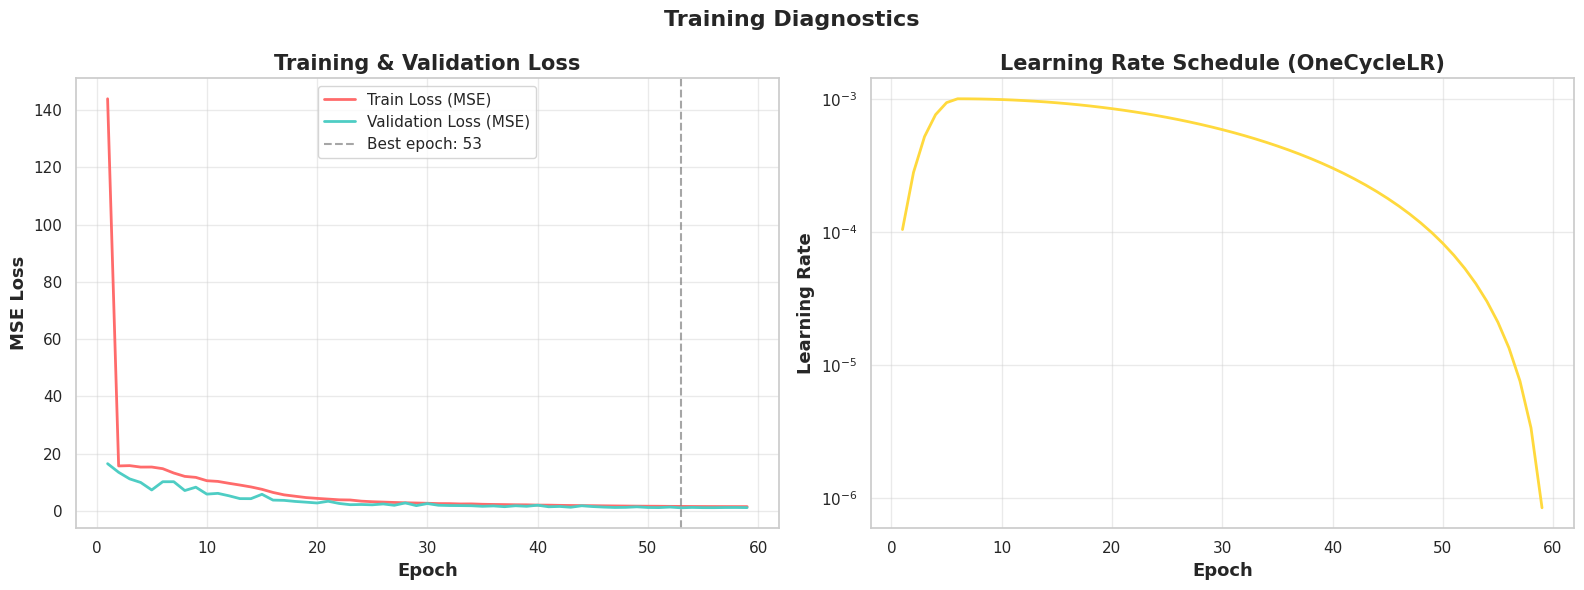

Best Val Loss: 1.0345 at epoch 53
Final Train Loss: 1.4494
Final Val Loss:   1.1022


In [24]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


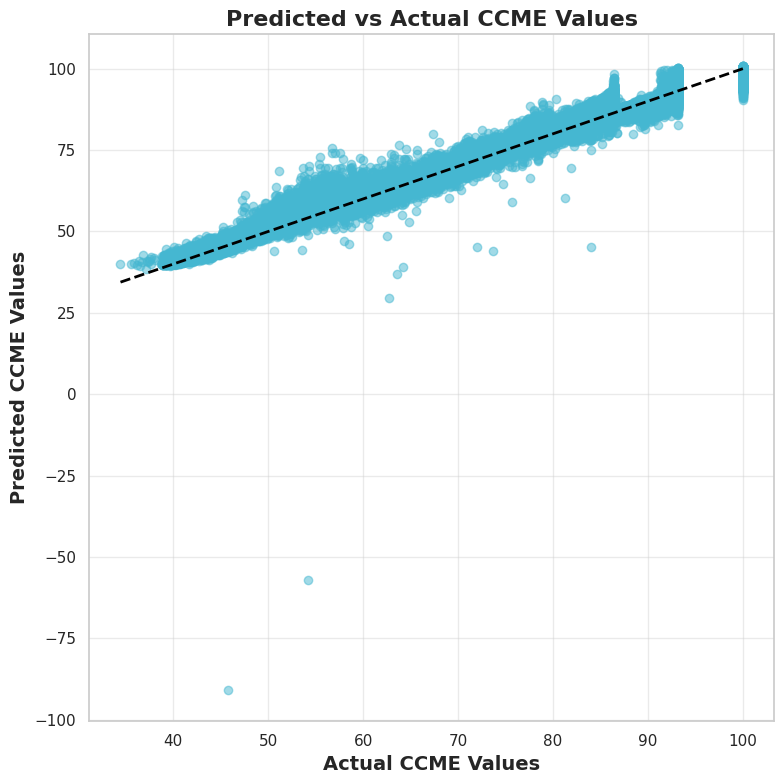

In [25]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



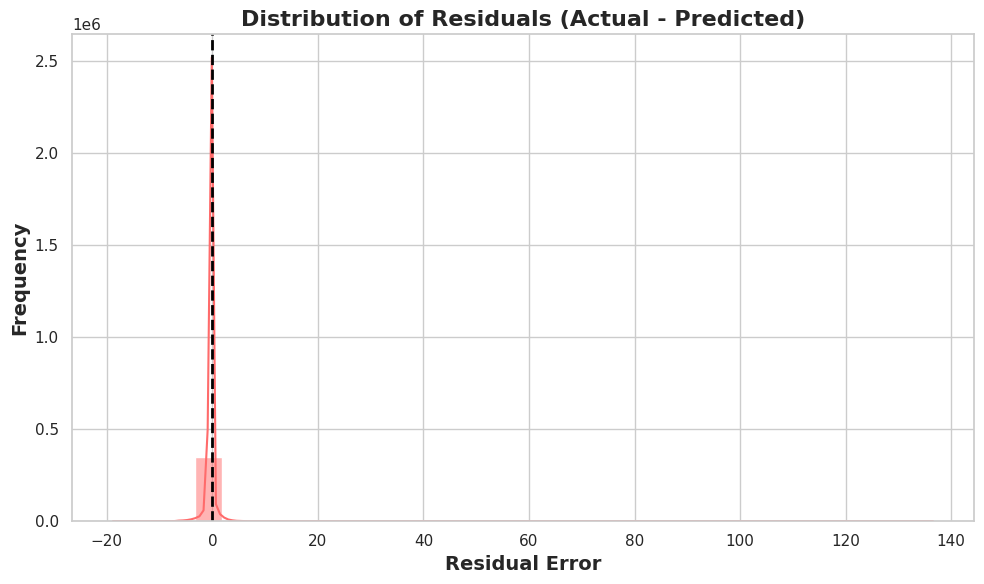

In [26]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric  Value                                      Description
     MSE 1.0666   Mean Squared Error – average squared deviation
    RMSE 1.0327 Root Mean Squared Error – in original CCME units
     MAE 0.5026 Mean Absolute Error – average absolute deviation
R² Score 0.9961 Coefficient of Determination – 1.0 = perfect fit


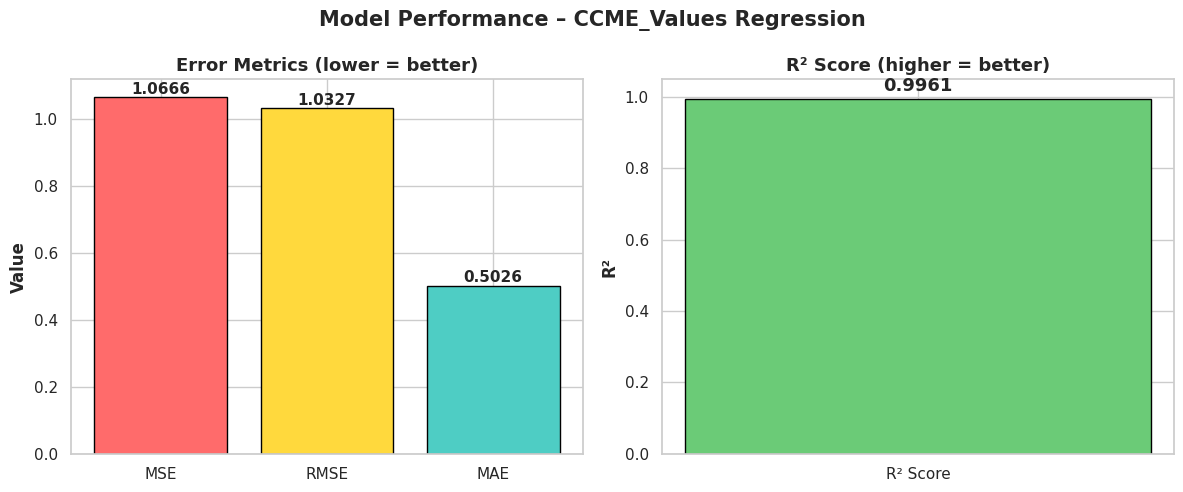

In [27]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting Attention Rollout Heatmaps...
['Ammonia_mg_l', 'Biochemical_Oxygen_Demand_mg_l', 'Dissolved_Oxygen_mg_l', 'Orthophosphate_mg_l', 'pH_ph_units', 'Temperature_cel', 'Nitrogen_mg_l', 'Nitrate_mg_l', 'Month_sin', 'Month_cos', 'Waterbody_Type_Artificial', 'Waterbody_Type_Coastal_Marine', 'Waterbody_Type_Lake', 'Waterbody_Type_Minor_Waterbodies', 'Waterbody_Type_River', 'Waterbody_Type_Wastewater']


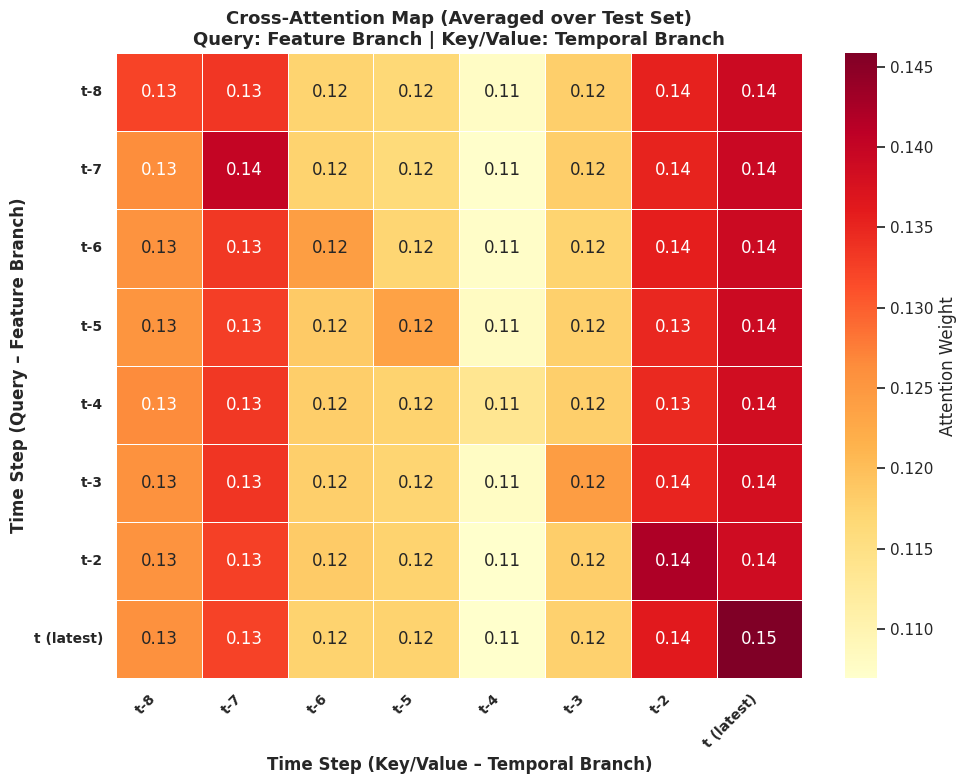

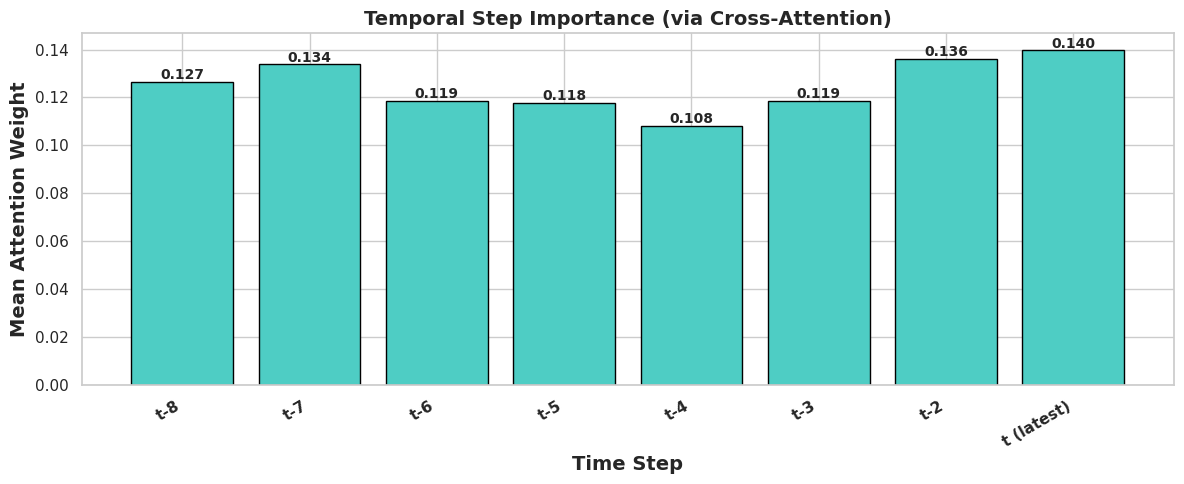

In [ ]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Attention Rollout Heatmap
# ─────────────────────────────────────────────
print("\n[XAI] Extracting Attention Rollout Heatmaps...")
SEQ_LEN = 8
feature_names = X_train.columns.tolist()
print(feature_names)
model.eval()

attn_maps_all = []   # collect over test batches
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_maps_all.append(model.last_attn_weights.cpu().numpy())  # [B, T, T]

attn_maps_all = np.concatenate(attn_maps_all, axis=0)   # [N, T, T]

# Global: mean cross-attention over test set
mean_attn = attn_maps_all.mean(axis=0)    # [T, T]

 
time_step_labels = [f"t-{SEQ_LEN - i}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mean_attn, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attention Weight'},
            xticklabels=time_step_labels,    
            yticklabels=time_step_labels)    
ax.set_title('Cross-Attention Map (Averaged over Test Set)\n'
             'Query: Feature Branch | Key/Value: Temporal Branch',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step (Key/Value – Temporal Branch)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Step (Query – Feature Branch)',       fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,   fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-time-step importance vector –  
time_importance = mean_attn.mean(axis=0)   # [T]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, time_importance, color='#4ECDC4', edgecolor='black')
for bar, val in zip(bars, time_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Attention Weight', fontsize=14, fontweight='bold')
ax.set_title('Temporal Step Importance (via Cross-Attention)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()



[XAI] SHAP Gradient Explainer...
shap_values shape after normalization: (50, 8, 16)


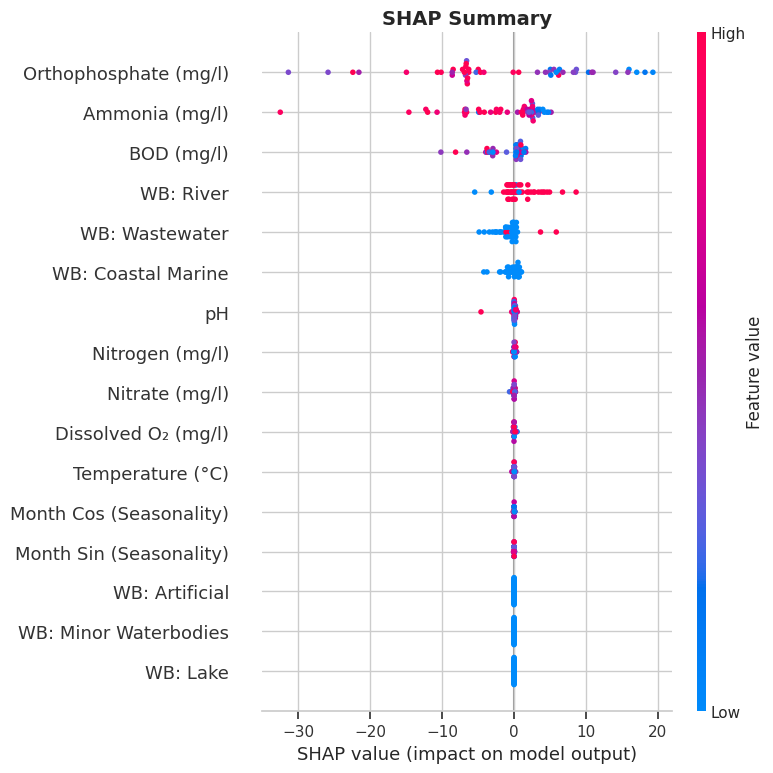

shap_means shape: (16,) | len features: 16


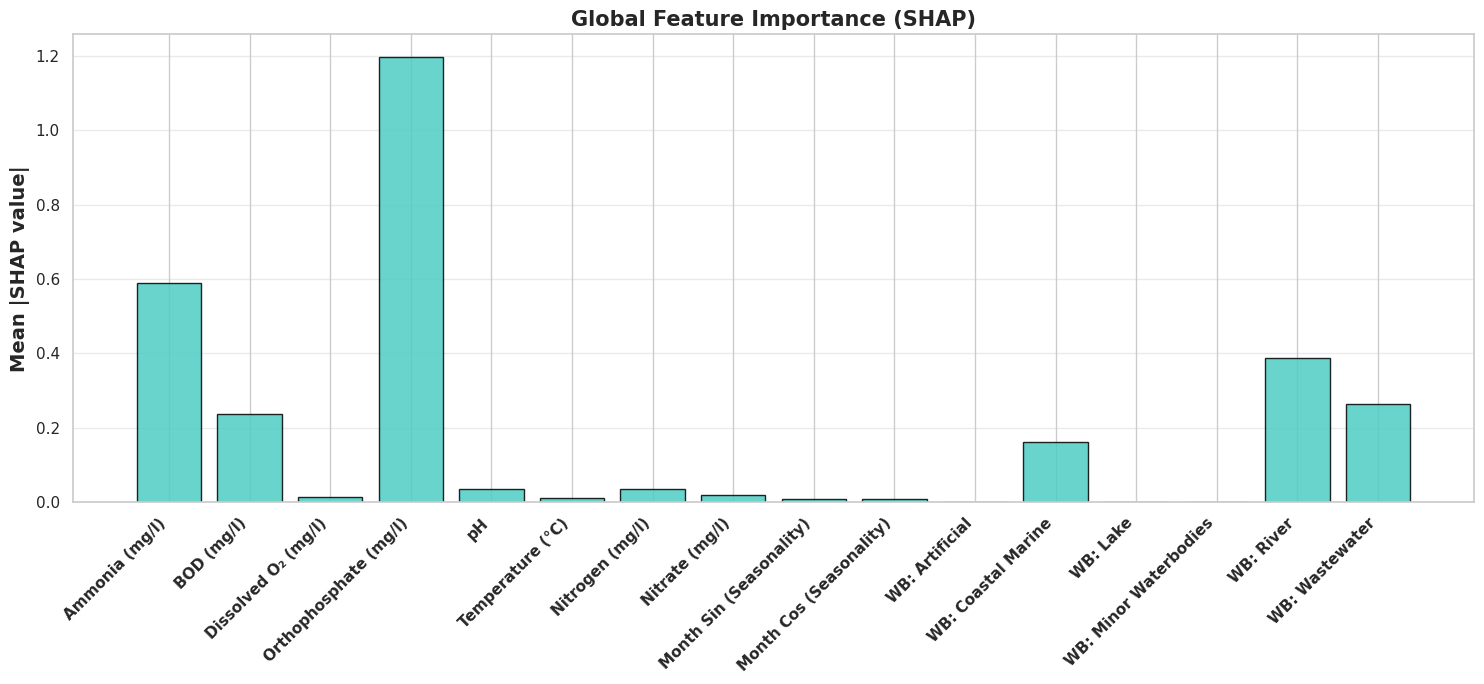

In [29]:

# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap
import numpy as np

print("\n[XAI] SHAP Gradient Explainer...")
background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)
test_sample = X_test_t[:50]   # already on device

shap_raw = explainer.shap_values(test_sample)

# ──────────────────────────────────────────────────────────────────────
# ✅ ROBUST FIX: Normalize shap_values to shape [N, T, F] regardless of
# what SHAP version returns. Possible raw shapes:
#   • list of [N, T, F]        ← SHAP < 0.40
#   • list of [N, T, F, 1]     ← SHAP 0.40-0.41
#   • ndarray [N, T, F]        ← some versions
#   • ndarray [N, T, F, 1]     ← other versions
# ──────────────────────────────────────────────────────────────────────
def normalize_shap(sv):
    """Always returns a plain float64 ndarray of shape [N, T, F]."""
    # Step 1: unwrap list → take first element (single-output model)
    if isinstance(sv, list):
        sv = sv[0]
    # Step 2: convert to numpy float64 (handles torch tensors too)
    sv = np.asarray(sv, dtype=np.float64)
    # Step 3: squeeze any trailing size-1 dims until we reach 3D [N, T, F]
    while sv.ndim > 3:
        if sv.shape[-1] == 1:
            sv = sv[..., 0]   # drop trailing output-dim
        elif sv.shape[0] == 1:
            sv = sv[0]        # drop leading wrapper-dim
        else:
            break             # unexpected shape — stop and let print below show it
    return sv

shap_values = normalize_shap(shap_raw)
print(f"shap_values shape after normalization: {shap_values.shape}")
# Expected: (50, 8, F)  where F = number of features
assert shap_values.ndim == 3, f"Unexpected SHAP shape: {shap_values.shape}"

# ── Feature name mapping ─────────────────────────────────────────────
raw_feature_names = X_train.columns.tolist()
feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O₂ (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (°C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}
feature_names_display = [
    feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
    for c in raw_feature_names
]

# ── SHAP Summary Plot ────────────────────────────────────────────────
test_np  = test_sample.cpu().numpy()
input_2d = test_np.mean(axis=1)       # [50, T, F] → mean over T → [50, F]
sv_2d    = shap_values.sum(axis=1)    # [50, T, F] → sum  over T → [50, F]

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_2d, input_2d, feature_names=feature_names_display, show=False)
plt.title("SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Global Feature Importance Bar ───────────────────────────────────
# mean over N (samples) and T (time steps) → 1-D array of shape [F]
shap_means = np.abs(shap_values).mean(axis=(0, 1)).flatten()  # always 1-D ✅
print(f"shap_means shape: {shap_means.shape} | len features: {len(feature_names_display)}")

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(feature_names_display))
ax.bar(x, shap_means, color='#4ECDC4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# End of notebook — Dual-Branch Transformer Regression on CCME_Values
